<a href="https://colab.research.google.com/github/barco8336-star/Inteligencia-de-Negocios/blob/main/Analisis_Diagnostico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
library(tidyverse)
library(lubridate)
library(readr)
library(dplyr)
library(readxl)

In [ ]:
churn <- read_xlsx("AnaliticaDiagnosticaR.xlsx", sheet = "Churn")

head(churn)

customer_id,support_tickets,last_purchase_days_ago,device_used,tenure_months,total_spend,used_promo_code,churn_prob,churned
<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<lgl>
1,3,111,Desktop,30,1322.53,TRUE,0.1155,FALSE
2,3,86,Mobile,39,710.38,TRUE,0.1430,FALSE
3,0,77,Mobile,17,665.62,TRUE,0.0785,FALSE
4,2,127,Desktop,19,1411.26,TRUE,0.1035,FALSE
5,1,72,Mobile,2,609.87,FALSE,0.0960,FALSE
6,1,34,Mobile,8,694.07,FALSE,0.0770,FALSE


Hipótesis 1 (Mal Servicio): Los clientes que contactan a soporte son más propensos a darse de
baja, lo que sugiere una mala experiencia de servicio al cliente.

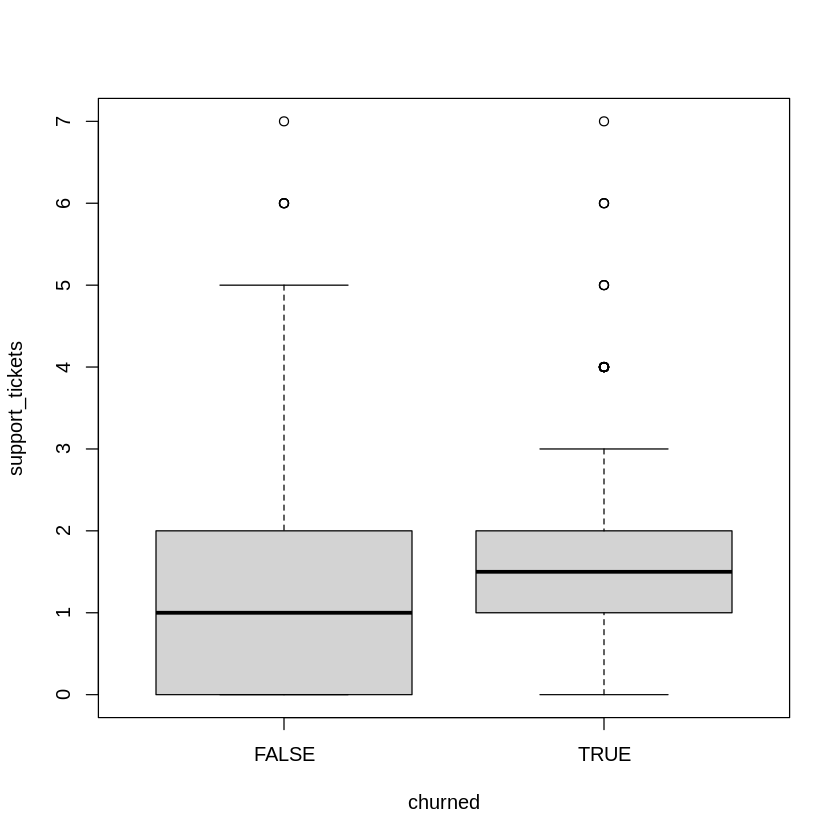

In [ ]:
boxplot(support_tickets ~ churned, data=churn)

In [ ]:
t.test(support_tickets ~ churned, data = churn)
'Si es estadisticamente significativa la diferencia entre el tiempo de support tickets de los que son baja'


	Welch Two Sample t-test

data:  support_tickets by churned
t = -7.292, df = 498.25, p-value = 1.208e-12
alternative hypothesis: true difference in means between group FALSE and group TRUE is not equal to 0
95 percent confidence interval:
 -0.5535429 -0.3185654
sample estimates:
mean in group FALSE  mean in group TRUE 
           1.177899            1.613953 


Hipótesis 2 (Sensibilidad al Precio): Los clientes que no usaron un código promocional son más
sensibles al precio y más propensos a darse de baja.


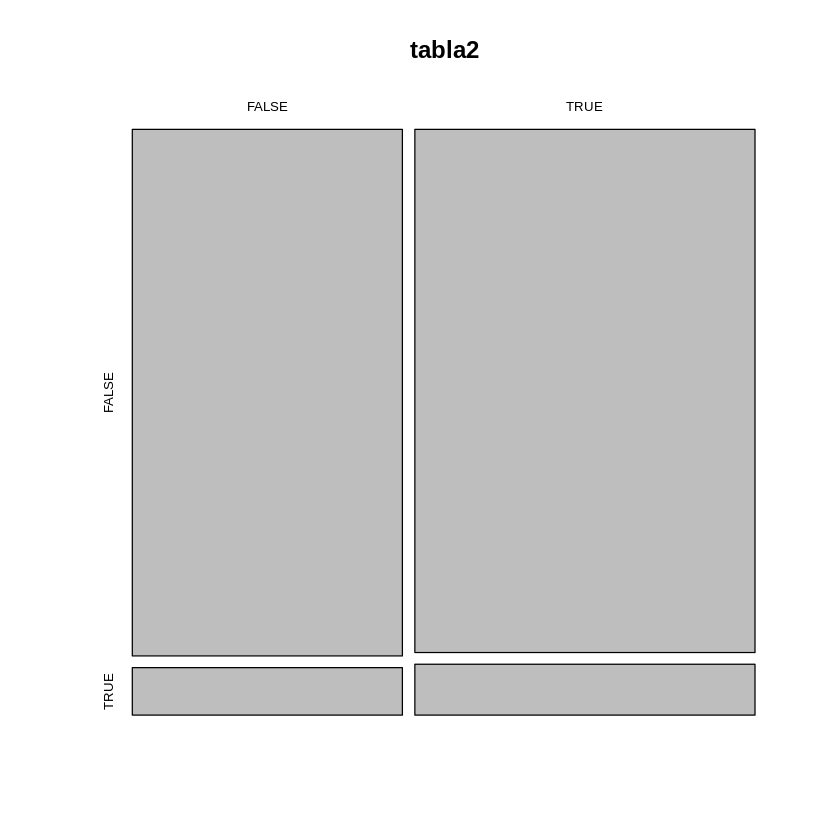

In [ ]:
tabla2 = table(churn$used_promo_code, churn$churned)
mosaicplot(tabla2)

In [ ]:
chisq.test(tabla2)
'No tienen relacion los datos'


	Pearson's Chi-squared test with Yates' continuity correction

data:  tabla2
X-squared = 0.47943, df = 1, p-value = 0.4887


Hipótesis 3 (Compromiso/Interacción): Los clientes que están menos comprometidos (ej., no
han comprado recientemente) son más propensos a darse de baja.


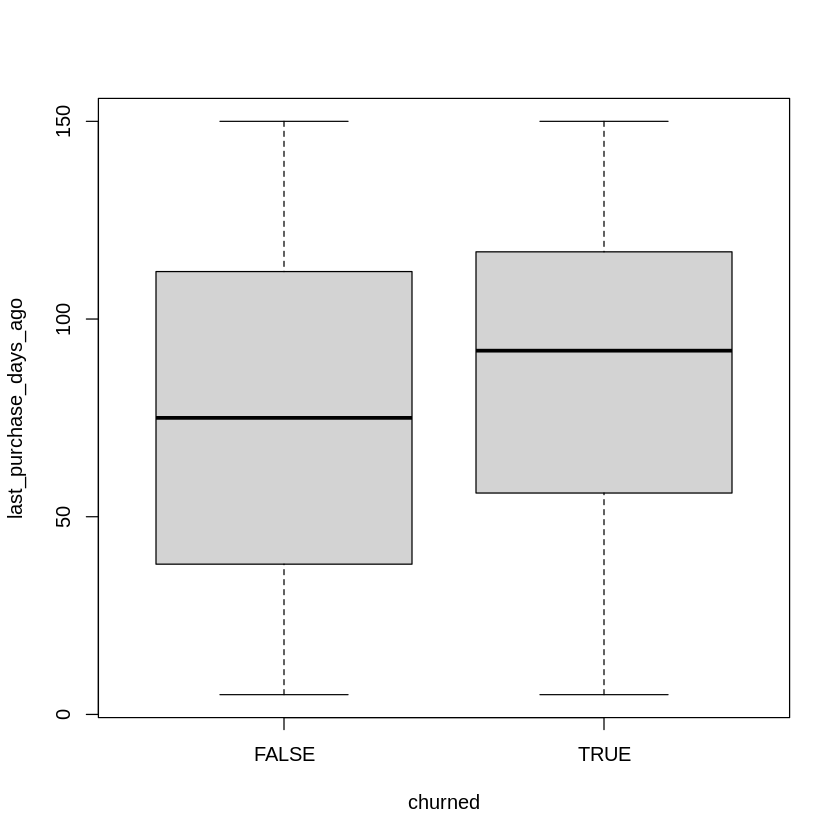

In [ ]:
boxplot(last_purchase_days_ago	~ churned, data = churn)

In [ ]:
t.test(last_purchase_days_ago	~ churned, data = churn)
'El tiempo de la ultima compra si es significativa entre ambas variables'


	Welch Two Sample t-test

data:  last_purchase_days_ago by churned
t = -4.9206, df = 525.26, p-value = 1.157e-06
alternative hypothesis: true difference in means between group FALSE and group TRUE is not equal to 0
95 percent confidence interval:
 -13.830602  -5.938143
sample estimates:
mean in group FALSE  mean in group TRUE 
           75.88074            85.76512 


Hipótesis 4 (Problemas Técnicos): Una actualización reciente de la aplicación/sitio web causó
problemas a los usuarios en una plataforma específica (ej., móvil), provocando la fuga.

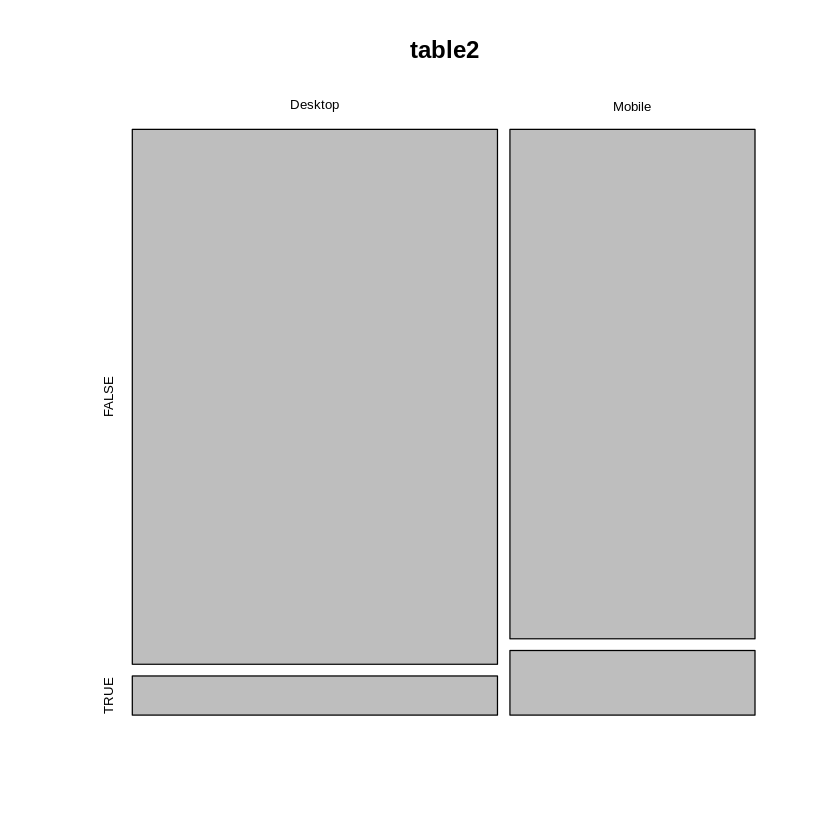

In [ ]:
table2 <- table(churn$device_used, churn$churned)
mosaicplot(table2)
'La diferencia entre la proporcion de lo que abandonaron de los que tienen aplicacion mobile'

In [ ]:
chisq.test(table2)
'El hecho de usar una plataforma o otra si incide en la decion de abandonar o no'


	Pearson's Chi-squared test with Yates' continuity correction

data:  table2
X-squared = 29.53, df = 1, p-value = 5.505e-08


#CASO 2

In [ ]:
Turnover <- read_xlsx("AnaliticaDiagnosticaR.xlsx", sheet = "Turnover")
head(Turnover)

employee_id,department,last_promotion_years,manager_id,avg_overtime_hrs_wk,satisfaction_score_1_5,salary,left_company
<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<lgl>
1,Engineering,1.659287,Manager B,9,3.6,80063,FALSE
2,Engineering,2.154734,Manager B,9,1.5,79401,FALSE
3,Engineering,4.838062,Manager A,6,2.0,94730,FALSE
4,Engineering,2.605763,Manager A,7,4.3,93017,FALSE
5,Engineering,2.693932,Manager A,6,4.2,56760,FALSE
6,Engineering,5.072597,Manager D,12,1.2,110609,FALSE


1. Compensación: Los ingenieros se van por salarios más altos en otros lugares.

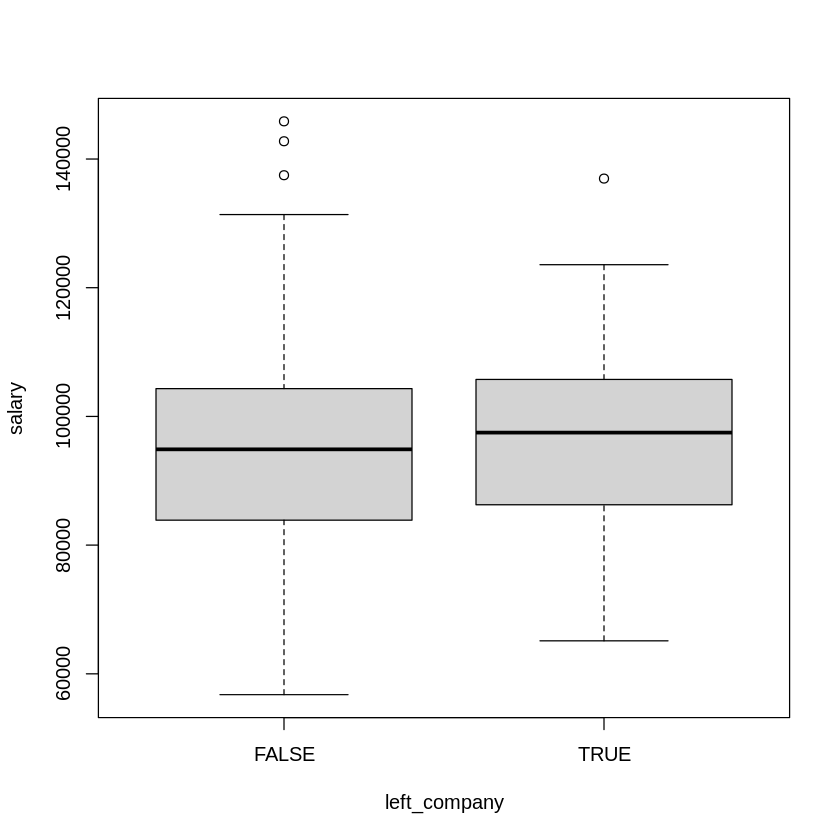

In [ ]:
boxplot(salary ~ left_company, data = Turnover)

In [ ]:
t.test(salary ~ left_company, data = Turnover)
'No existe diferencia significativa entre la variables es decir el salario no es un
factor por la cual la gente se va de la empresa.'


	Welch Two Sample t-test

data:  salary by left_company
t = -0.35642, df = 94.405, p-value = 0.7223
alternative hypothesis: true difference in means between group FALSE and group TRUE is not equal to 0
95 percent confidence interval:
 -4544.385  3161.095
sample estimates:
mean in group FALSE  mean in group TRUE 
           95030.16            95721.80 


2. Equilibrio Vida-Trabajo: El exceso de horas extras está llevando al agotamiento (burnout).

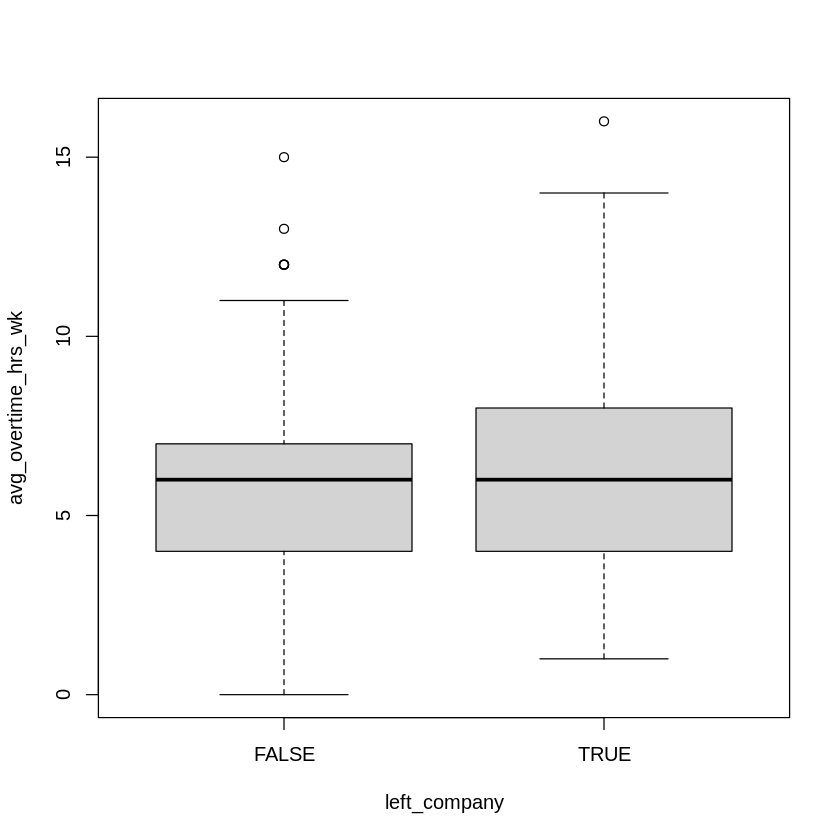

In [ ]:
boxplot(avg_overtime_hrs_wk ~ left_company, data = Turnover)
'Igual en ambos grupos hay gente que trabaj mucho tiempo'

In [ ]:
t.test(avg_overtime_hrs_wk ~ left_company, data = Turnover)
'No tiene relacion significativa las variables'


	Welch Two Sample t-test

data:  avg_overtime_hrs_wk by left_company
t = -1.9792, df = 79.767, p-value = 0.05125
alternative hypothesis: true difference in means between group FALSE and group TRUE is not equal to 0
95 percent confidence interval:
 -1.585560798  0.004389731
sample estimates:
mean in group FALSE  mean in group TRUE 
           5.794030            6.584615 


Crecimiento Profesional: La falta de ascensos o de desarrollo profesional está causando
estancamiento.

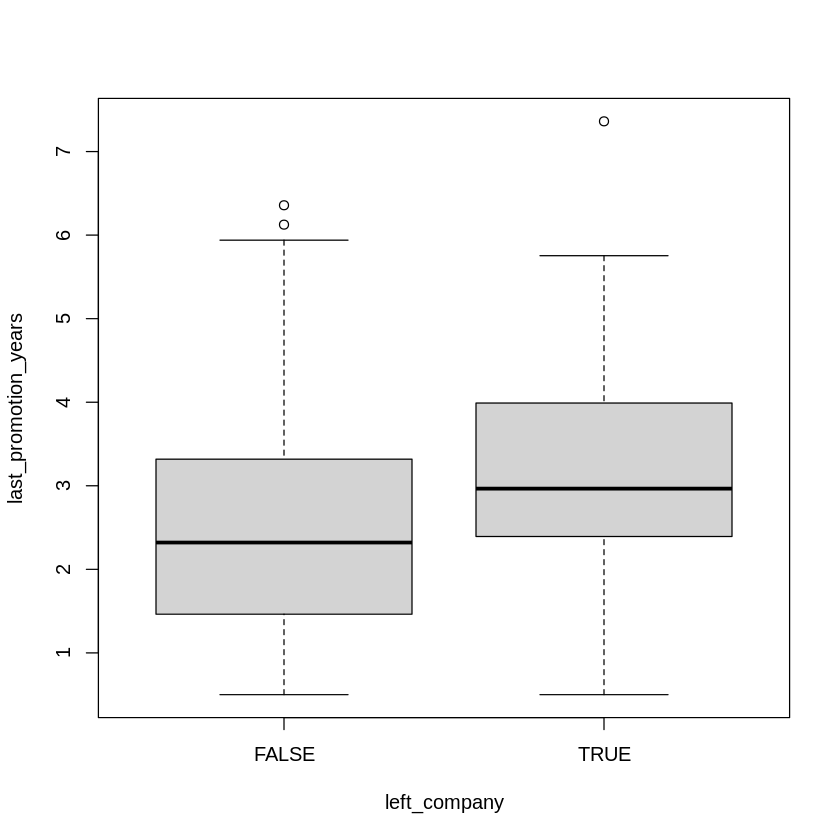

In [ ]:
boxplot(last_promotion_years ~ left_company, data = Turnover)
'En este grafico si se observa una diferencia entre el tiempo de la ultima promocion siendo mayor para los que rotaron'

In [ ]:
t.test(last_promotion_years ~ left_company, data = Turnover)
'Si es significativa la diferencia entre las variables es la relacion etre las variables
si es significativa y puede ser una causa probable.'


	Welch Two Sample t-test

data:  last_promotion_years by left_company
t = -3.5939, df = 90.441, p-value = 0.00053
alternative hypothesis: true difference in means between group FALSE and group TRUE is not equal to 0
95 percent confidence interval:
 -1.0293814 -0.2964932
sample estimates:
mean in group FALSE  mean in group TRUE 
           2.459716            3.122653 


Gestión/Dirección: Un gerente o grupo de gerentes específico podría tener un estilo que está
ahuyentando a la gente.

           
            FALSE TRUE
  Manager A   100   21
  Manager B   118   12
  Manager C    58   24
  Manager D    59    8

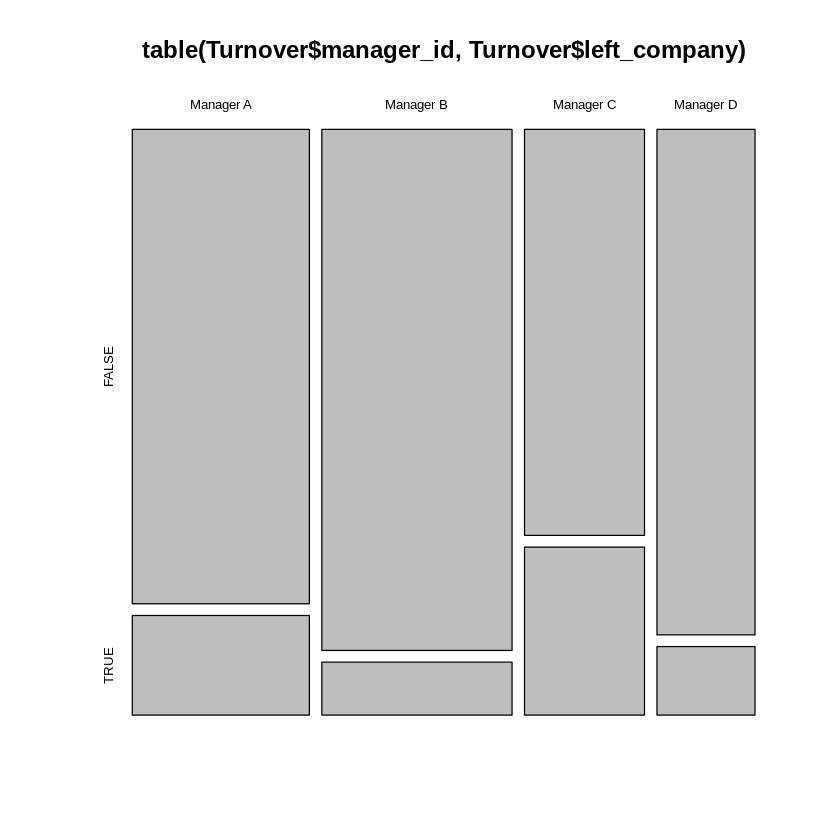

In [ ]:
table(Turnover$manager_id , Turnover$left_company)
mosaicplot(table(Turnover$manager_id , Turnover$left_company))

In [ ]:
chisq.test(table(Turnover$manager_id , Turnover$left_company))


	Pearson's Chi-squared test

data:  table(Turnover$manager_id, Turnover$left_company)
X-squared = 15.941, df = 3, p-value = 0.001166


#Caso 3

Que esta causando el aumento en los defectos

In [ ]:
Manufactura <- read_xlsx("AnaliticaDiagnosticaR.xlsx", sheet = "Manufactura")
head(Manufactura)

batch_id,line_id,machine_id,supplier,operator_id,ambient_temp_c,num_defects,defect_rate
<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,Line 2,M2-A,Supplier Alpha,Op-2,22.16917,8,0.008
2,Line 2,M2-C,Supplier Alpha,Op-3,20.82070,12,0.012
3,Line 2,M2-A,Supplier Beta,Op-5,18.98700,10,0.010
4,Line 2,M2-B,Supplier Alpha,Op-3,20.87795,37,0.037
5,Line 2,M2-C,Supplier Gamma (new),Op-1,19.64772,29,0.029
6,Line 2,M2-A,Supplier Gamma (new),Op-2,19.27907,22,0.022


Específico de la Máquina: Una máquina en particular de la línea no funciona correctamente.

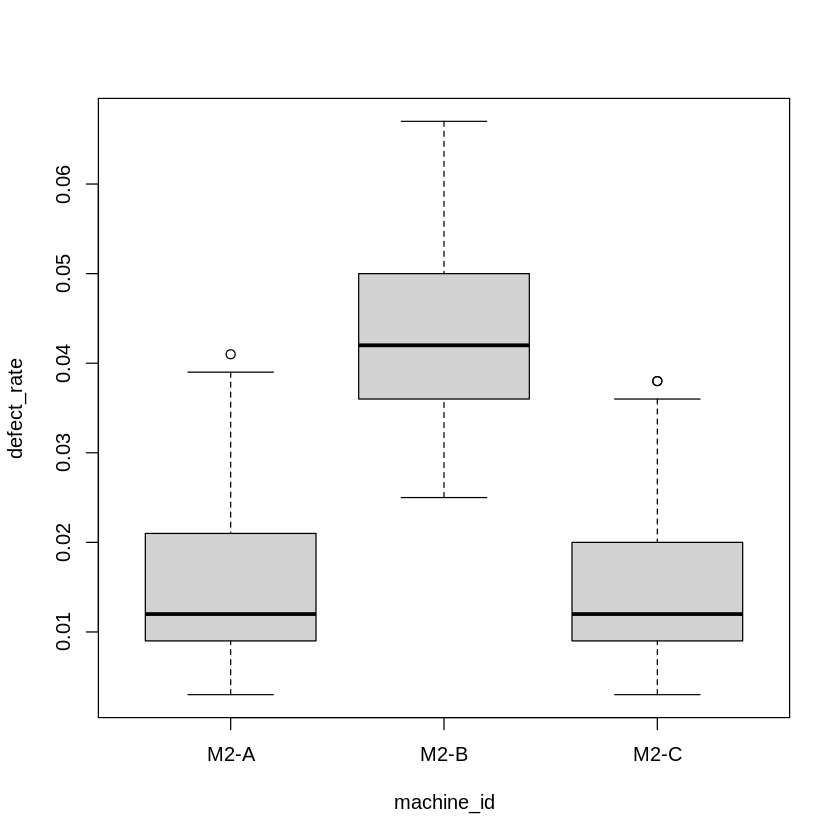

In [ ]:
boxplot(defect_rate ~ machine_id, data = Manufactura)
'Si se observa que la maguina b tiene en promedio un porcentaje mayor de defectos'

In [ ]:
'Anova: Tenemos mas de 2 grupos por lo tanto se aplica el analisis de varianza
(ANOVA)'

ANOVA <- aov(defect_rate ~ machine_id, data = Manufactura)
summary(ANOVA)
'Nos indica que si hay una diferencia significativa entre las medias de los grupos'

[1] "Anova: Tenemos mas de 2 grupos por lo tanto se aplica el analisis de varianza\n(ANOVA)"

             Df  Sum Sq Mean Sq F value Pr(>F)    
machine_id    2 0.13703 0.06852   990.5 <2e-16 ***
Residuals   997 0.06896 0.00007                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [ ]:
tukey_result <- TukeyHSD(ANOVA)
tukey_result
'Esto nos indica donde es que esta la diferente
se debe de analizar el p adj en este caso la diferente es B'

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = defect_rate ~ machine_id, data = Manufactura)

$machine_id
                   diff          lwr          upr     p adj
M2-B-M2-A  2.928407e-02  0.027594112  0.030974038 0.0000000
M2-C-M2-A -7.267116e-05 -0.001452274  0.001306931 0.9916076
M2-C-M2-B -2.935675e-02 -0.031053024 -0.027660467 0.0000000


2. Específico del Operador: Un operador nuevo o mal capacitado está cometiendo errores.


             Df  Sum Sq   Mean Sq F value Pr(>F)
operator_id   4 0.00123 0.0003063   1.488  0.204
Residuals   995 0.20477 0.0002058               

[1] "No es menor a 0.05 por lo que no es significativa"

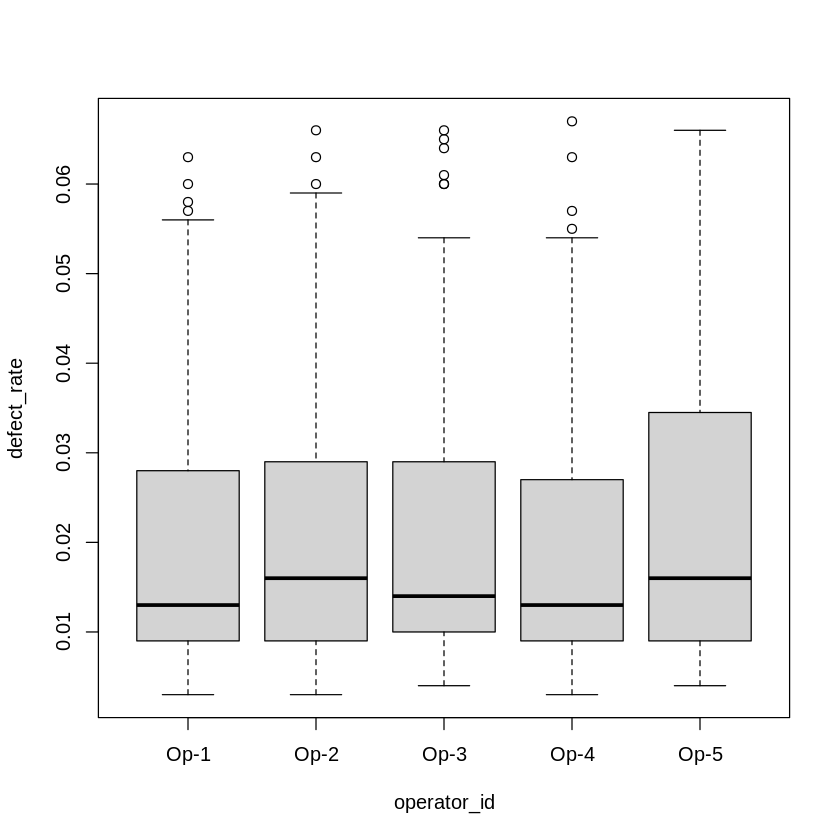

In [ ]:
boxplot(defect_rate ~ operator_id, data = Manufactura)
ANOVA <- aov(defect_rate ~ operator_id, data = Manufactura)
summary(ANOVA)
'No es menor a 0.05 por lo que no es significativa'

3. Específico del Proveedor: Un lote de materias primas de un nuevo proveedor es defectuoso.


             Df  Sum Sq  Mean Sq F value Pr(>F)    
supplier      2 0.04764 0.023819     150 <2e-16 ***
Residuals   997 0.15835 0.000159                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

[1] "No es menor a 0.05 por lo que no es significativa"

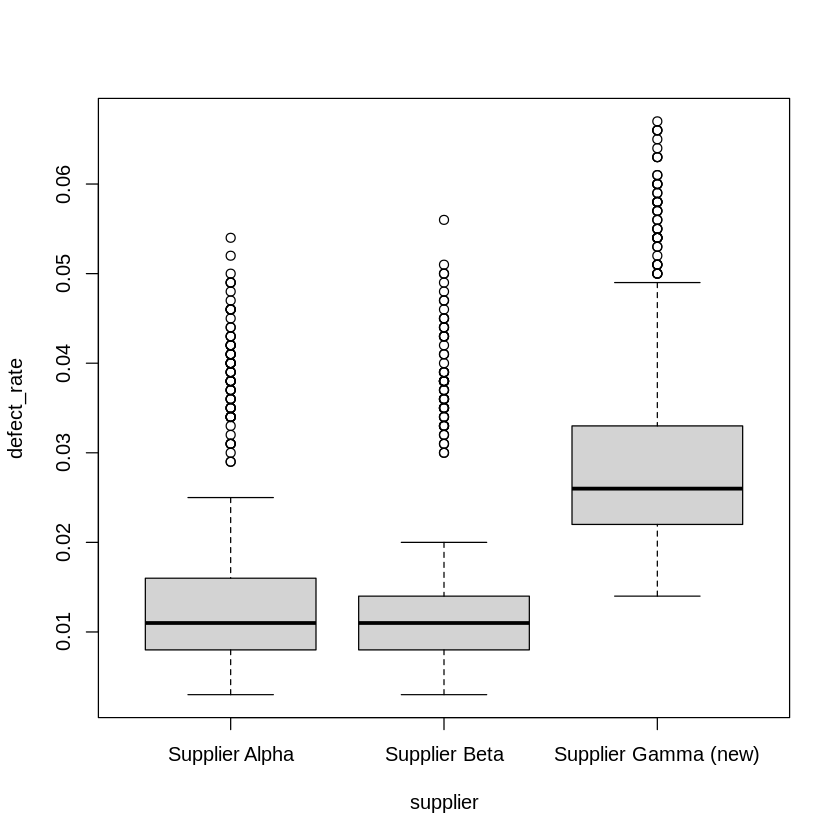

In [ ]:
boxplot(defect_rate ~ supplier, data = Manufactura)
ANOVA <- aov(defect_rate ~ supplier, data = Manufactura)
summary(ANOVA)
'El proveedor es una causa en los defectos'
'Analisis de Interraciones'

In [ ]:
TukeyHSD(ANOVA)
'La diferencia esta en el supplir gamma'

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = defect_rate ~ supplier, data = Manufactura)

$supplier
                                            diff          lwr        upr
Supplier Beta-Supplier Alpha        -0.001207097 -0.003457954 0.00104376
Supplier Gamma (new)-Supplier Alpha  0.014286042  0.011962662 0.01660942
Supplier Gamma (new)-Supplier Beta   0.015493139  0.013184003 0.01780228
                                        p adj
Supplier Beta-Supplier Alpha        0.4189703
Supplier Gamma (new)-Supplier Alpha 0.0000000
Supplier Gamma (new)-Supplier Beta  0.0000000


Ambiental: Un cambio en los parámetros operativos (ej., temperatura, humedad) está afectando
la calidad.

[1] -0.0001227155

`geom_smooth()` using formula = 'y ~ x'



Call:
lm(formula = defect_rate ~ ambient_temp_c, data = Manufactura)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.017380 -0.011377 -0.006377  0.008622  0.046622 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     2.040e-02  5.059e-03   4.032 5.95e-05 ***
ambient_temp_c -8.878e-07  2.290e-04  -0.004    0.997    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.01437 on 998 degrees of freedom
Multiple R-squared:  1.506e-08,	Adjusted R-squared:  -0.001002 
F-statistic: 1.503e-05 on 1 and 998 DF,  p-value: 0.9969


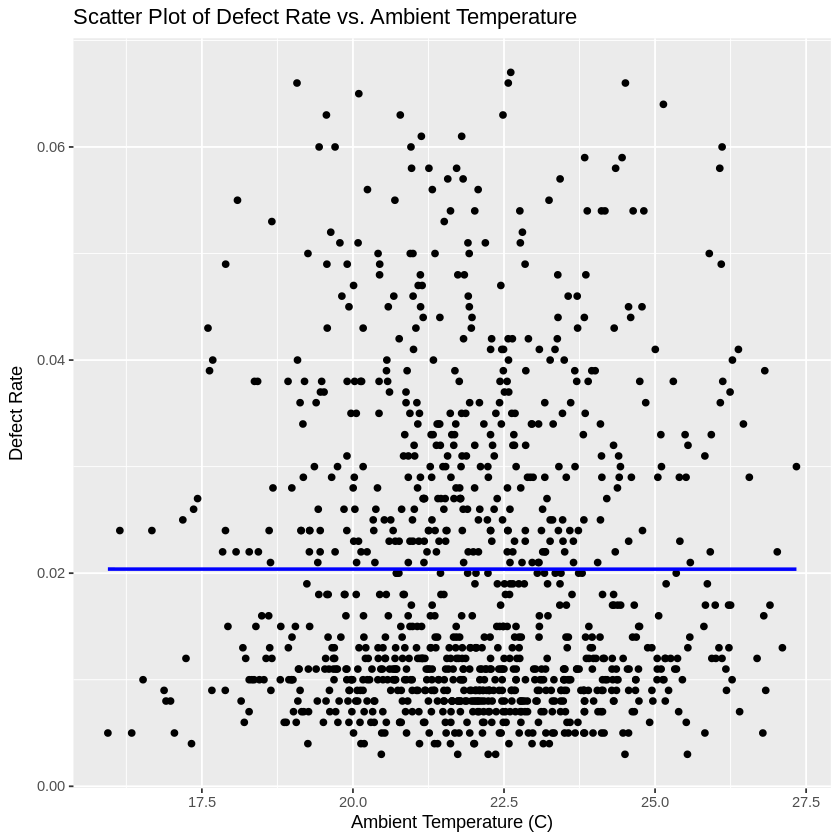

In [ ]:
cor(Manufactura$ambient_temp_c,Manufactura$defect_rate)

ggplot(Manufactura, aes(x = ambient_temp_c, y = defect_rate)) +
  geom_point() +
  labs(title = "Scatter Plot of Defect Rate vs. Ambient Temperature",
       x = "Ambient Temperature (C)",
       y = "Defect Rate") +
  geom_smooth(method = "lm", se = FALSE, color = "blue")

modelo1 <- lm(defect_rate ~ ambient_temp_c, data =  Manufactura)
summary(modelo1)
'No hay relacion'